In [6]:
print("OCR EDEN")

OCR EDEN


In [7]:
import pytesseract
print("Tesseract importé avec succès")

Tesseract importé avec succès


In [8]:
from pdf2image import convert_from_path

pages = convert_from_path("../data/raw/facture_test.pdf")

print(len(pages))

2


Nombre de pages : 2


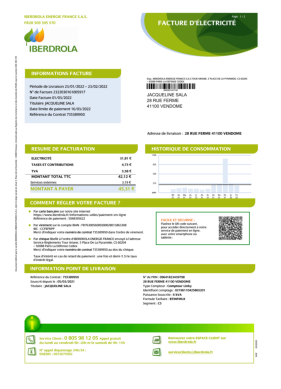

In [9]:
from pdf2image import convert_from_path
import matplotlib.pyplot as plt

pages = convert_from_path("../data/raw/facture_test.pdf")

print("Nombre de pages :", len(pages))

plt.imshow(pages[0])
plt.axis("off")
plt.show()

In [10]:
import pytesseract
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

text = pytesseract.image_to_string(pages[0], lang="eng")

print(text[:1000])

Document délivré par la société IBERDROLA ENERGIE FRANCE S.A.S,, dont le siége social est situé 5, Place de la Pyramide - 92800 Puteaux, immatriculée au Registre du Commerce et des Sociétés de PARIS sous le numéro 509 395 570

IBERDROLA ENERGIE FRANCE S.A.S.
FR28 509 395 570

IBERDROLA

INFORMATIONS FACTURE

Période de Livraison 23/01/2022 — 23/02/2022
N° de Facture 2322030161005917

Date Facture 01/03/2022

Titulaire JACQUELINE SALA

Date limite de paiement 16/03/2022
Référence du Contrat 735389950

RESUME DE FACTURATION

ELECTRICITE 31,81 €
TAXES ET CONTRIBUTIONS 4,73 €
TVA 5,58 €
MONTANT TOTAL TTC 42,12 €
Services externes 3,19€
MONTANT A PAYER 45,31 €

COMMENT REGLER VOTRE FACTURE ?

@ Par carte bancaire sur notre site internet
https://www.iberdrola.fr/informations-utiles/paiement-en-ligne
Référence de paiement : 5048395622

@ Par virement sur le compte IBAN : FR763005600028002801 3863308
BIC : CCFRFRPP

Merci d'indiquer votre numéro de contrat 735389950 dans l'ordre de virement.



In [11]:
import re

match = re.search(r"(\d+)\s*kWh", text)

if match:
    electricity_kwh = int(match.group(1))
else:
    electricity_kwh = None

print(electricity_kwh)

None


In [12]:
for line in text.split("\n"):
    if "kWh" in line:
        print(line)

In [13]:
print(text[:3000])

Document délivré par la société IBERDROLA ENERGIE FRANCE S.A.S,, dont le siége social est situé 5, Place de la Pyramide - 92800 Puteaux, immatriculée au Registre du Commerce et des Sociétés de PARIS sous le numéro 509 395 570

IBERDROLA ENERGIE FRANCE S.A.S.
FR28 509 395 570

IBERDROLA

INFORMATIONS FACTURE

Période de Livraison 23/01/2022 — 23/02/2022
N° de Facture 2322030161005917

Date Facture 01/03/2022

Titulaire JACQUELINE SALA

Date limite de paiement 16/03/2022
Référence du Contrat 735389950

RESUME DE FACTURATION

ELECTRICITE 31,81 €
TAXES ET CONTRIBUTIONS 4,73 €
TVA 5,58 €
MONTANT TOTAL TTC 42,12 €
Services externes 3,19€
MONTANT A PAYER 45,31 €

COMMENT REGLER VOTRE FACTURE ?

@ Par carte bancaire sur notre site internet
https://www.iberdrola.fr/informations-utiles/paiement-en-ligne
Référence de paiement : 5048395622

@ Par virement sur le compte IBAN : FR763005600028002801 3863308
BIC : CCFRFRPP

Merci d'indiquer votre numéro de contrat 735389950 dans l'ordre de virement.



In [14]:
text2 = pytesseract.image_to_string(pages[1], lang="eng")

print(text2)

Page 2/2

FACTURATION

ABONNEMENT
Abonnement 31 jours x 0,330162 €/jour 10,24 €
TOTAL ABONNEMENT 10,24 €
CONSOMMATION
Terme d'énergie 215 kWh x 0,100322 €/kWh 21,57€
TOTAL CONSOMMATION 21,57 €
TOTAL ELECTRICITE 31,81€
TAXES ET CONTRIBUTIONS
Taxe communale sur la consommation finale d'électricité 215 kWh x 0,00663 €/kWh 1,43 €
(TCCFE)
Taxe Intérieure sur la Consommation Finale d'Electricité 55,48 kWh x 0,0258291 €/kwh 1,43 €
(TICFE) (23/01/2022-31/01/2022)
Taxe Intérieure sur la Consommation Finale d'Electricité 159,52 kWh x 0,001 €/kWh 0,16 €
(TICFE) (31/01/2022-23/02/2022)
Contribution Tarifaire d'Acheminement (CTA) 7,81 € x 21,93 % 1,71€
TOTAL TAXES ET CONTRIBUTIONS 4,73 €
TVA
TVA Taux normal 24,59 € x 20 % 4,92€
TVA Taux réduit 11,95 €x5,5 % 0,66 €
5,58 €
MONTANT TOTAL 42,12 €
SERVICE ATOUT PRIX
Atout Prix Elec 1,08 mois x 2,95 €/mois 3,19€
TOTAL SERVICE ATOUT PRIX 3,19 €

CONSOMMATION

CONCEPT. DU AU ANCIEN INDEX NOUVEL INDEX CONSOMMATION (kWh) TYPE

Energie HPH 23/01/2022 23/02/20

In [15]:
import re

match = re.search(r"(\d+)\s*kWh", text2)

print(match.group(1))

215


In [16]:
import re

match = re.search(r"(\d+)\s*kWh", text2)

if match:
    electricity_kwh = int(match.group(1))
else:
    electricity_kwh = None

result = {
    "electricity_kwh": electricity_kwh,
    "gas_m3": None,
    "waste_tons": None,
    "logistics_km": None
}

print(result)

{'electricity_kwh': 215, 'gas_m3': None, 'waste_tons': None, 'logistics_km': None}


In [17]:
from dotenv import load_dotenv
import os

load_dotenv()

print(os.getenv("HF_TOKEN")[:10])

hf_epnSZbD


In [18]:
from openai import OpenAI

client = OpenAI(
    base_url="https://router.huggingface.co/v1",
    api_key=os.getenv("HF_TOKEN")
)

In [19]:
try:
    response = client.chat.completions.create(
        model="openai/gpt-oss-20b",
        messages=[
            {
                "role": "user",
                "content": "Bonjour"
            }
        ],
        max_tokens=50
    )

    print(response)
    
except Exception as e:
    print(e)

ChatCompletion(id='chatcmpl-e8747efd-8d44-4f82-a129-6c1c2140d97f', choices=[Choice(finish_reason='length', index=0, logprobs=None, message=ChatCompletionMessage(content='Bonjour\u202f! Comment', refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=None, reasoning='The user says "Bonjour". This is a greeting. Should respond politely. Probably in French, maybe say "Bonjour ! En quoi puis-je vous aider aujourd’hui ?" Should keep friendly.'))], created=1781789243, model='openai/gpt-oss-20b', object='chat.completion', moderation=None, service_tier='on_demand', system_fingerprint='fp_35b6cecc66', usage=CompletionUsage(completion_tokens=50, prompt_tokens=72, total_tokens=122, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=None, audio_tokens=None, reasoning_tokens=38, rejected_prediction_tokens=None), prompt_tokens_details=None, queue_time=0.048751609, prompt_time=0.003409849, completion_time=0.051942362, total_time=0.055352

In [20]:
prompt = f"""
Tu es un assistant spécialisé dans les factures d'énergie.

Extrais les informations suivantes et retourne uniquement un JSON valide :

- electricity_kwh
- gas_m3
- waste_tons
- logistics_km

Texte :

{text2}
"""

response = client.chat.completions.create(
    model="openai/gpt-oss-20b",
    messages=[
        {
            "role": "user",
            "content": prompt
        }
    ],
    max_tokens=300
)

print(response.choices[0].message.content)

```json
{
  "electricity_kwh": 215,
  "gas_m3": null,
  "waste_tons": null,
  "logistics_km": null
}
```
